# MIRI 21/7.7 micron ratio and continuum-subtracted H2 on one rotated sky grid

This notebook follows the sky cutout, rotation, WCS axes, footprint styling, and annotations in `plot_miri_rgb_rotated_wcs.ipynb`. It saves one MIRI F2100W/F770W ratio plot and one continuum-subtracted H2 F470N-F480M plot using a combined `binary` and Colorcet `fire` colormap.

In [19]:
from pathlib import Path

import astropy.units as u
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import colorcet as cc
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.lines import Line2D
from scipy.ndimage import binary_fill_holes, map_coordinates

# Input files
MIRI_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/jwst/fits/nanfilled/reprojected')
F2100W_FITS = MIRI_DIR / 'jw07230-o002_t003_miri_f2100w_i2d_nanfilled_reprojected.fits'
F770W_FITS = MIRI_DIR / 'jw07230-o002_t003_miri_f770w_i2d_nanfilled_reprojected.fits'
H2_FITS = Path('/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/cloud_H_JWST/NIRCam/12-05-2026/contsub/H2_F470N_minus_F480M_contsub.fits')

# Match the active display controls in plot_miri_rgb_rotated_wcs.ipynb.
DISPLAY_RA = '18h57m06.9897195423s'
DISPLAY_DEC = '2d10m15.3794463101s'
DISPLAY_WIDTH_ARCMIN = 3.1892713314
DISPLAY_HEIGHT_ARCMIN = 6.3763691658
DISPLAY_PA_DEG = 341.5270170076544 - 360

# Put the long supplied dimension across the page, keeping the mosaic horizontal.
PLOT_WIDTH_ARCMIN = DISPLAY_HEIGHT_ARCMIN
PLOT_HEIGHT_ARCMIN = DISPLAY_WIDTH_ARCMIN
OUTPUT_DIR = Path('./../plots')
INTERPOLATION = 'bilinear'

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [20]:
def make_combined_colormap(n_low=100, n_high=256, name='binary_fire'):
    """Stack Matplotlib binary below Colorcet fire."""
    binary = plt.get_cmap('binary').resampled(n_low)
    fire = cc.cm.fire.resampled(n_high)
    colors = np.vstack((
        binary(np.linspace(0, 1, n_low)),
        fire(np.linspace(0, 1, n_high)),
    ))
    return mcolors.LinearSegmentedColormap.from_list(name, colors)


combined_cmap = make_combined_colormap()
combined_cmap.set_bad('black')

In [21]:
# Read the science arrays and their own celestial WCS solutions.
with fits.open(F2100W_FITS, memmap=True) as hdul:
    f2100w = np.asarray(hdul[1].data, dtype=float)
    f2100w_wcs = WCS(hdul[1].header).celestial

with fits.open(F770W_FITS, memmap=True) as hdul:
    f770w = np.asarray(hdul[1].data, dtype=float)
    f770w_wcs = WCS(hdul[1].header).celestial

with fits.open(H2_FITS, memmap=True) as hdul:
    h2 = np.asarray(hdul['SCI'].data, dtype=float)
    h2_wcs = WCS(hdul['SCI'].header).celestial

print(f'F2100W: {f2100w.shape[1]} x {f2100w.shape[0]} pixels')
print(f'F770W: {f770w.shape[1]} x {f770w.shape[0]} pixels')
print(f'H2: {h2.shape[1]} x {h2.shape[0]} pixels')

F2100W: 1364 x 3185 pixels
F770W: 1364 x 3185 pixels
H2: 5641 x 2506 pixels


Set DATE-AVG to '2026-04-20T19:13:48.581' from MJD-AVG.
Set DATE-END to '2026-04-20T20:21:51.119' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.247298 from OBSGEO-[XYZ].
Set OBSGEO-H to 1505726645.939 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2026-04-20T19:13:48.581' from MJD-AVG.
Set DATE-END to '2026-04-20T20:21:51.119' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.247298 from OBSGEO-[XYZ].
Set OBSGEO-H to 1505726645.939 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2026-05-12T01:02:15.728' from MJD-AVG.
Set DATE-END to '2026-05-12T01:20:47.025' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.317589 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674214111.642 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [22]:
# Build the same rotated output WCS as the reference RGB notebook.
display_center = SkyCoord(DISPLAY_RA, DISPLAY_DEC, frame='icrs')
miri_pixel_scale = (np.mean(proj_plane_pixel_scales(f770w_wcs)) * u.deg).to_value(u.arcsec)
display_width_pixels = int(np.ceil(PLOT_WIDTH_ARCMIN * 60 / miri_pixel_scale))
display_height_pixels = int(np.ceil(PLOT_HEIGHT_ARCMIN * 60 / miri_pixel_scale))

wcs_rotation_rad = np.deg2rad(DISPLAY_PA_DEG + 90)
rotation_matrix = np.array([
    [np.cos(wcs_rotation_rad), -np.sin(wcs_rotation_rad)],
    [np.sin(wcs_rotation_rad),  np.cos(wcs_rotation_rad)],
])

display_wcs = WCS(naxis=2)
display_wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN']
display_wcs.wcs.cunit = ['deg', 'deg']
display_wcs.wcs.crval = [display_center.ra.deg, display_center.dec.deg]
display_wcs.wcs.crpix = [(display_width_pixels + 1) / 2, (display_height_pixels + 1) / 2]
display_wcs.wcs.cdelt = [miri_pixel_scale / 3600, miri_pixel_scale / 3600]
display_wcs.wcs.pc = np.array([[-1, 0], [0, 1]]) @ rotation_matrix
display_wcs.wcs.set()

display_y, display_x = np.mgrid[0:display_height_pixels, 0:display_width_pixels]
ra, dec = display_wcs.pixel_to_world_values(display_x, display_y)
print(f'Display grid: {display_width_pixels} x {display_height_pixels} pixels')
print(f'MIRI display pixel scale: {miri_pixel_scale:.4f} arcsec/pixel')

Display grid: 3449 x 1726 pixels
MIRI display pixel scale: 0.1109 arcsec/pixel


In [27]:
# Sample each input independently in world coordinates, then form the ratio.
f2100w_x, f2100w_y = f2100w_wcs.world_to_pixel_values(ra, dec)
f770w_x, f770w_y = f770w_wcs.world_to_pixel_values(ra, dec)
h2_x, h2_y = h2_wcs.world_to_pixel_values(ra, dec)

display_f2100w = map_coordinates(f2100w, [f2100w_y, f2100w_x], order=1, mode='constant', cval=np.nan)
display_f770w = map_coordinates(f770w, [f770w_y, f770w_x], order=1, mode='constant', cval=np.nan)
display_h2 = map_coordinates(h2, [h2_y, h2_x], order=1, mode='constant', cval=np.nan)

ratio_valid = np.isfinite(display_f2100w) & np.isfinite(display_f770w) & (display_f770w > 0)
display_ratio = np.full(display_f2100w.shape, np.nan)
display_ratio[ratio_valid] = display_f2100w[ratio_valid] / display_f770w[ratio_valid]

ratio_fov = binary_fill_holes(ratio_valid)
h2_fov = binary_fill_holes(np.isfinite(display_h2))

ratio_limits = np.nanpercentile(display_ratio[ratio_valid], [1, 99.9])
h2_limits = np.nanpercentile(display_h2[h2_fov], [30, 99.5])
ratio_norm = ImageNormalize(vmin=ratio_limits[0], vmax=ratio_limits[1], stretch=AsinhStretch(0.1), clip=False)
h2_norm = ImageNormalize(vmin=h2_limits[0], vmax=h2_limits[1], stretch=AsinhStretch(0.1), clip=False)

print(f'F2100W/F770W display limits: {ratio_limits[0]:.3g} to {ratio_limits[1]:.3g}')
print(f'H2 display limits: {h2_limits[0]:.3g} to {h2_limits[1]:.3g} MJy/sr')

F2100W/F770W display limits: 5.1 to 31.9
H2 display limits: -0.0627 to 2.57 MJy/sr


Saved ../plots/miri_f2100w_f770w_ratio_rotated_wcs.pdf
Saved ../plots/h2_f470n_minus_f480m_rotated_wcs.pdf


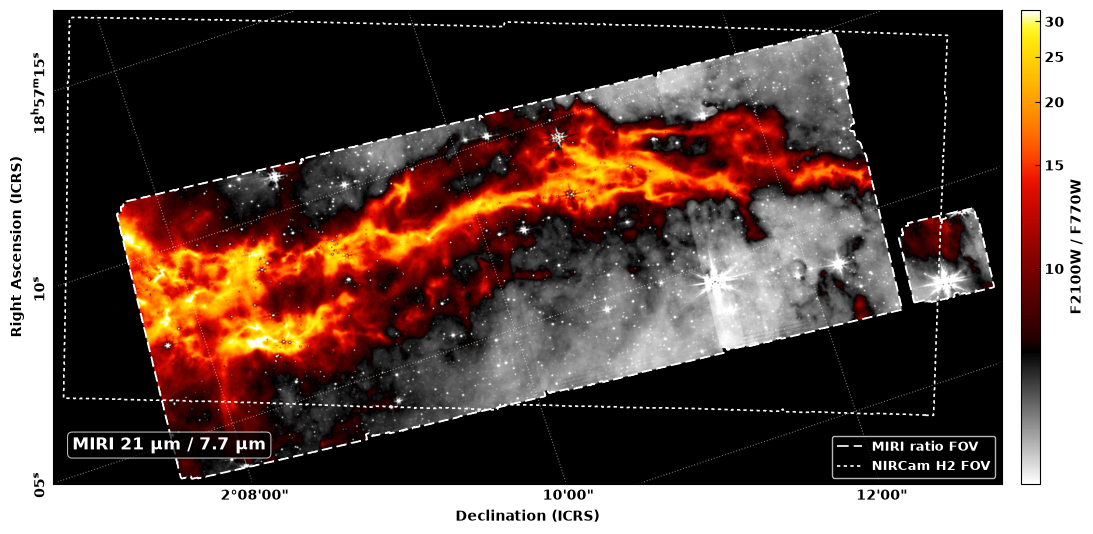

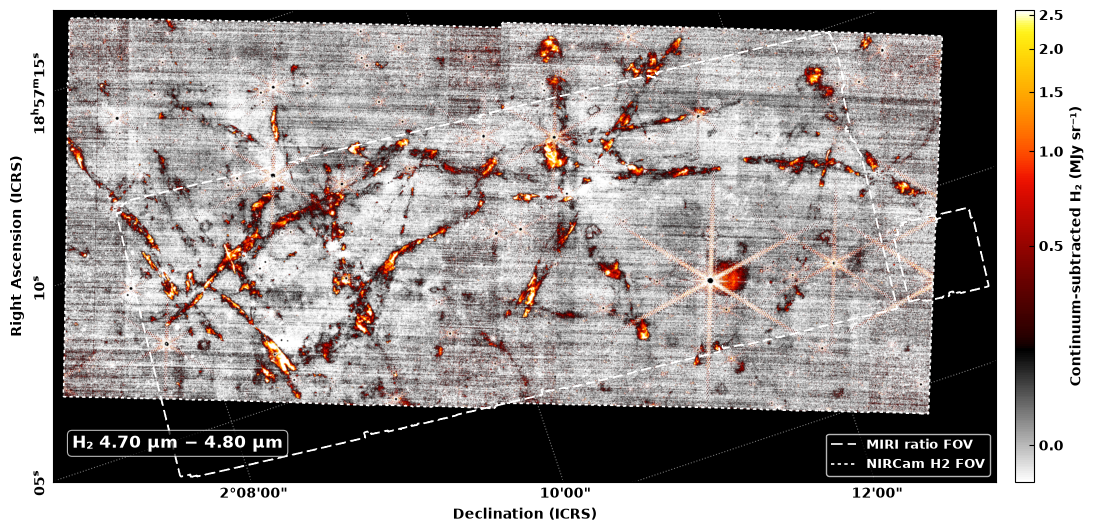

In [28]:
# Plot both maps with the reference notebook's coordinates, orientation, and styling.
fov_legend = [
    Line2D([0], [0], color='white', linewidth=1.2, linestyle=(0, (7, 3)), label='MIRI ratio FOV'),
    Line2D([0], [0], color='white', linewidth=1.2, linestyle=(0, (2, 2)), label='NIRCam H2 FOV'),
]

plots = [
    (display_ratio, ratio_norm, 'MIRI 21 μm / 7.7 μm', 'F2100W / F770W',
     OUTPUT_DIR / 'miri_f2100w_f770w_ratio_rotated_wcs.pdf'),
    (display_h2, h2_norm, 'H₂ 4.70 μm − 4.80 μm', 'Continuum-subtracted H₂ (MJy sr⁻¹)',
     OUTPUT_DIR / 'h2_f470n_minus_f480m_rotated_wcs.pdf'),
]

for image, norm, title, colorbar_label, output_file in plots:
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(1, 1, 1, projection=display_wcs)
    ax.set_facecolor('black')
    shown = ax.imshow(
        np.ma.masked_invalid(image), origin='lower', interpolation=INTERPOLATION,
        cmap=combined_cmap, norm=norm,
    )
    ax.contour(
        ratio_fov.astype(float), levels=[0.5], colors='white',
        linewidths=1.2, linestyles=[(0, (7, 3))], origin='lower',
    )
    ax.contour(
        h2_fov.astype(float), levels=[0.5], colors='white',
        linewidths=1.2, linestyles=[(0, (2, 2))], origin='lower',
    )
    ax.coords.grid(color='white', alpha=0.45, linestyle=':')
    ax.coords[0].set_axislabel('Right Ascension (ICRS)')
    ax.coords[1].set_axislabel('Declination (ICRS)')
    ax.coords[0].set_major_formatter('hh:mm:ss')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    ax.coords[0].set_ticklabel(rotation=90, ha='left', va='center')

    ax.text(
        0.02, 0.1, title, transform=ax.transAxes, ha='left', va='top',
        fontsize=12, fontweight='bold', color='white',
        bbox=dict(
            boxstyle='round,pad=0.28', facecolor='black', edgecolor='white',
            linewidth=0.8, alpha=0.72,
        ),
    )
    ax.legend(
        handles=fov_legend, loc='lower right', facecolor='black', edgecolor='white',
        framealpha=0.72, labelcolor='white', fontsize=9,
    )
    colorbar_ax = ax.inset_axes([1.02, 0, 0.02, 1.0])
    colorbar = fig.colorbar(shown, cax=colorbar_ax)
    colorbar.set_label(colorbar_label, fontweight='bold')

    fig.tight_layout()
    fig.savefig(output_file, dpi=300, bbox_inches='tight')
    # plt.close(fig)
    print(f'Saved {output_file}')